<a href="https://colab.research.google.com/github/preethu17/mystery17/blob/main/braintumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Error: /content/archive.zip not found.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (5).zip to archive (5).zip


In [7]:
import zipfile

with zipfile.ZipFile('archive (5).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

In [8]:
!ls '/content/dataset/'  # List extracted files

Testing  Training


In [9]:
import os

base_dir = '/content/dataset'
train_dir = os.path.join(base_dir, 'Training')
test_dir = os.path.join(base_dir, 'Testing')

print("Training subdirectories:", os.listdir(train_dir))
print("Testing subdirectories:", os.listdir(test_dir))

Training subdirectories: ['notumor', 'glioma', 'pituitary', 'meningioma']
Testing subdirectories: ['notumor', 'glioma', 'pituitary', 'meningioma']


Training set: {'notumor': 1595, 'glioma': 1321, 'pituitary': 1457, 'meningioma': 1339}
Testing set: {'notumor': 405, 'glioma': 300, 'pituitary': 300, 'meningioma': 306}


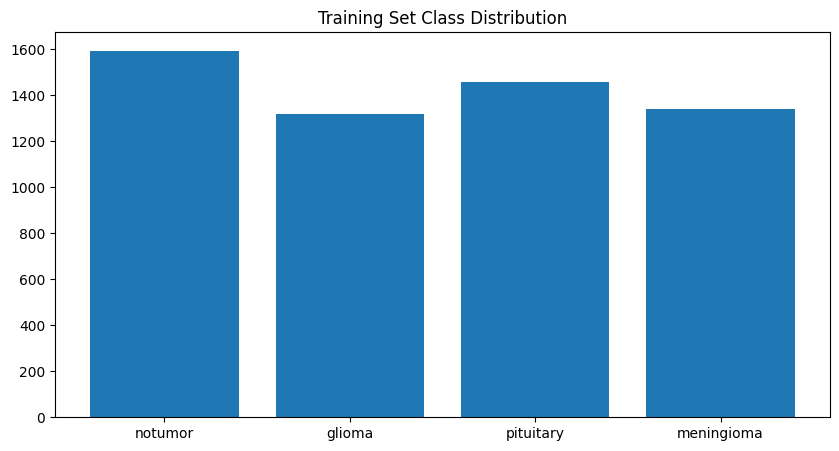

In [10]:
import matplotlib.pyplot as plt

def count_images(directory):
    counts = {}
    for folder in os.listdir(directory):
        folder_path = os.path.join(directory, folder)
        if os.path.isdir(folder_path):
            counts[folder] = len(os.listdir(folder_path))
    return counts

train_counts = count_images(train_dir)
test_counts = count_images(test_dir)

print("Training set:", train_counts)
print("Testing set:", test_counts)

# Visualize class distribution
plt.figure(figsize=(10, 5))
plt.bar(train_counts.keys(), train_counts.values())
plt.title('Training Set Class Distribution')
plt.show()

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image dimensions
img_height, img_width = 150, 150
batch_size = 32

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # Using 20% for validation
)

# Only rescaling for validation and test
test_datagen = ImageDataGenerator(rescale=1./255)

# Training generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Validation generator
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Test generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),

    Dense(512, activation='relu'),
    Dense(4, activation='softmax')  # 4 classes
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,813,508 (25.99 MB)

 Trainable params: 6,813,508 (25.99 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')

# Calculate steps
train_steps = max(1, train_generator.samples // batch_size)
val_steps = max(1, validation_generator.samples // batch_size)

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=val_steps,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

Epoch 1/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 290s 2s/step - accuracy: 0.6393 - loss: 0.8392 - val_accuracy: 0.6509 - val_loss: 0.9192
Epoch 2/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 41s 275ms/step - accuracy: 0.7188 - loss: 0.6705 - val_accuracy: 0.6714 - val_loss: 0.9101
Epoch 3/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.7264 - loss: 0.6678 - val_accuracy: 0.6670 - val_loss: 0.8667
Epoch 4/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 25s 166ms/step - accuracy: 0.5000 - loss: 1.1181 - val_accuracy: 0.6955 - val_loss: 0.8349
Epoch 5/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 382s 2s/step - accuracy: 0.7364 - loss: 0.6406 - val_accuracy: 0.7196 - val_loss: 0.7383
Epoch 6/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 26s 169ms/step - accuracy: 0.8125 - loss: 0.6302 - val_accuracy: 0.7455 - val_loss: 0.7269
Epoch 7/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.7743 - loss: 0.5572 - val_accuracy: 0.7321 - val_loss: 0.8240
Epoch 8/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 25s 160ms/step - accuracy: 0.7500 - loss: 0.6818 - 

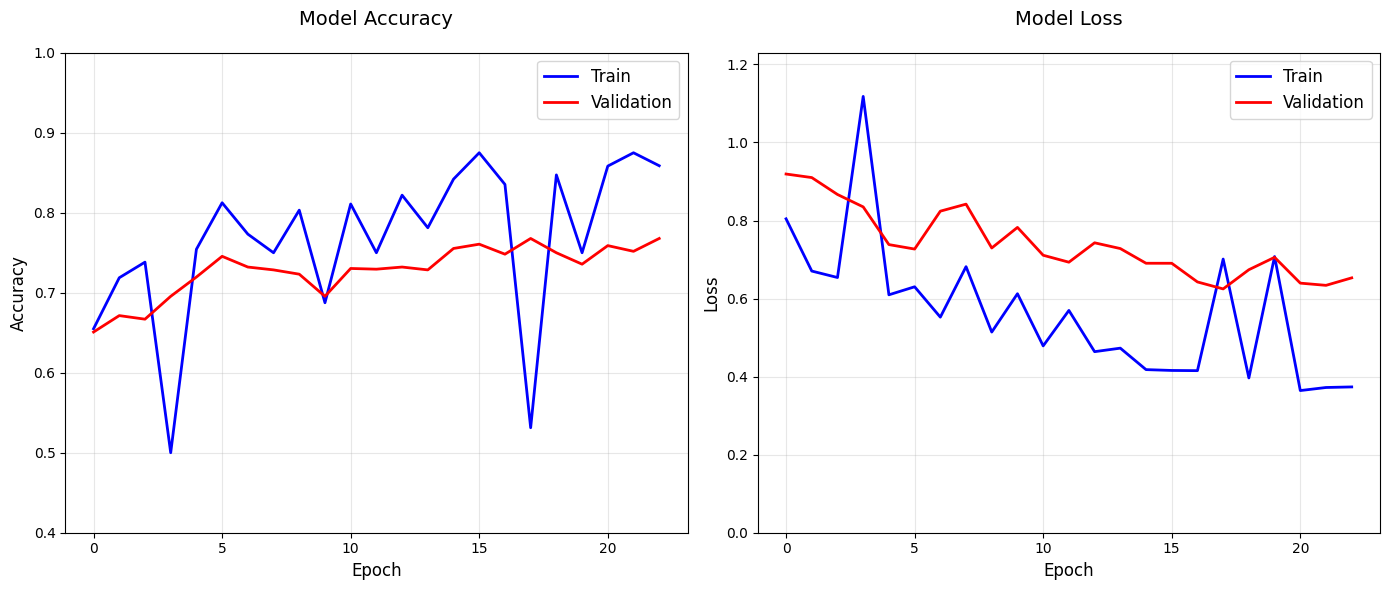

In [17]:
plt.figure(figsize=(14, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], 'b-', linewidth=2, label='Train')
plt.plot(history.history['val_accuracy'], 'r-', linewidth=2, label='Validation')
plt.title('Model Accuracy', fontsize=14, pad=20)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.ylim([0.4, 1.0])  # Set consistent y-axis
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], 'b-', linewidth=2, label='Train')
plt.plot(history.history['val_loss'], 'r-', linewidth=2, label='Validation')
plt.title('Model Loss', fontsize=14, pad=20)
plt.ylabel('Loss', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.ylim([0, max(history.history['loss']) * 1.1])  # Dynamic y-axis
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()  # Prevent label overlap
plt.show()

In [19]:
import os
print("Current directory:", os.getcwd())
print("Files in directory:", os.listdir())
print("Was best_model.h5 saved?", 'best_model.h5' in os.listdir())

Current directory: /content
Files in directory: ['.config', 'dataset', 'drive', 'archive (5).zip', 'best_model.keras', 'sample_data']
Was best_model.h5 saved? False


In [20]:
best_model = load_model('best_model.keras')  # Change extension to .keras
test_loss, test_acc = best_model.evaluate(test_generator)
print(f'Test accuracy: {test_acc:.4f}')

41/41 ━━━━━━━━━━━━━━━━━━━━ 22s 498ms/step - accuracy: 0.5796 - loss: 1.2178
Test accuracy: 0.7399


In [22]:
# Load the best saved model
from tensorflow.keras.models import load_model

best_model = load_model('best_model.keras')

# Evaluate on test set
test_loss, test_acc = best_model.evaluate(test_generator)
print(f'Test accuracy: {test_acc:.4f}')

41/41 ━━━━━━━━━━━━━━━━━━━━ 21s 489ms/step - accuracy: 0.5796 - loss: 1.2178
Test accuracy: 0.7399


41/41 ━━━━━━━━━━━━━━━━━━━━ 22s 541ms/step
Classification Report:
              precision    recall  f1-score   support

      glioma       0.95      0.50      0.65       300
  meningioma       0.63      0.44      0.52       306
     notumor       0.72      1.00      0.83       405
   pituitary       0.75      0.95      0.84       300

    accuracy                           0.74      1311
   macro avg       0.76      0.72      0.71      1311
weighted avg       0.76      0.74      0.72      1311



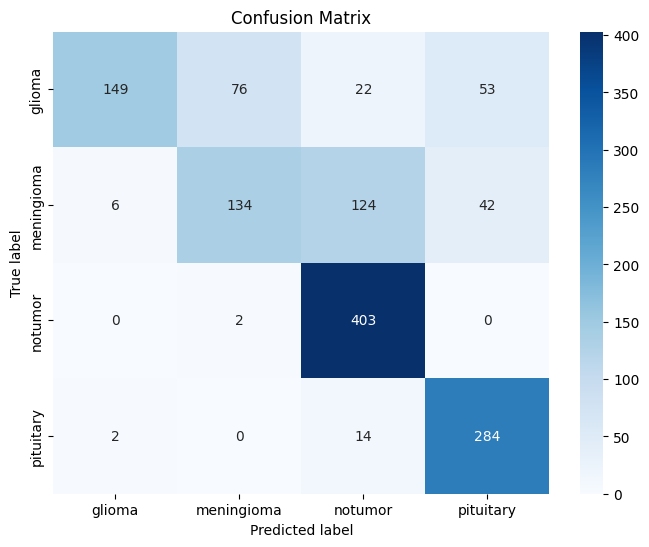

In [23]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get predictions
y_pred = best_model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices.keys()))

# Confusion matrix
conf_mat = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [25]:
# Save the model in the recommended format
best_model.save('brain_tumor_detection_model.keras')  # New recommended format

# Optionally save to Google Drive
!cp brain_tumor_detection_model.keras '/content/drive/MyDrive/'

# Later loading would use:
# best_model = load_model('brain_tumor_detection_model.keras')

In [26]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_tumor(image_path):
    # Load and preprocess the image
    img = image.load_img(image_path, target_size=(img_height, img_width))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    # Make prediction
    prediction = best_model.predict(img_array)
    class_idx = np.argmax(prediction)

    # Get class labels
    class_labels = list(test_generator.class_indices.keys())

    return {
        'class': class_labels[class_idx],
        'confidence': float(prediction[0][class_idx]),
        'all_predictions': {label: float(pred) for label, pred in zip(class_labels, prediction[0])}
    }

# Test the function with a sample image
sample_image_path = os.path.join(test_dir, 'glioma', 'Te-gl_0010.jpg')  # Replace with actual image path
print(predict_tumor(sample_image_path))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
{'class': 'pituitary', 'confidence': 0.4311177730560303, 'all_predictions': {'glioma': 0.29707109928131104, 'meningioma': 0.1739991158246994, 'notumor': 0.09781200438737869, 'pituitary': 0.4311177730560303}}


In [28]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.1/54.1 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.9/322.9 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 4.3 MB/s eta 0:00:00


In [34]:
import gradio as gr
import numpy as np
from PIL import Image

def classify_image(inp):
    # Convert Gradio's input to PIL Image if needed
    if isinstance(inp, np.ndarray):
        inp = Image.fromarray(inp)

    # Resize and preprocess
    inp = inp.resize((img_width, img_height))
    inp = np.array(inp).reshape((1, img_height, img_width, 3)).astype('float32') / 255.0
    prediction = best_model.predict(inp)
    class_labels = list(test_generator.class_indices.keys())
    return {label: float(pred) for label, pred in zip(class_labels, prediction[0])}

# Create interface
image_input = gr.Image(type="pil", label="Brain MRI Scan")
label_output = gr.Label(num_top_classes=4, label="Prediction")

# Prepare example images
example_images = [
    os.path.join(test_dir, 'glioma', 'Te-gl_0010.jpg'),
    os.path.join(test_dir, 'meningioma', 'Te-me_0010.jpg'),
    os.path.join(test_dir, 'pituitary', 'Te-pi_0010.jpg')
]

# Create and launch interface
interface = gr.Interface(
    fn=classify_image,
    inputs=image_input,
    outputs=label_output,
    title="Brain Tumor Classifier",
    description="Upload a brain MRI scan to classify tumor type",
    examples=example_images,
    allow_flagging="never"
)

# For interpretation (new method)
if hasattr(interface, "interpret"):  # For older Gradio versions
    interface.interpret = lambda x: {"original_image": x, "interpretation": None}
else:  # Newer versions may not support interpretation at all
    pass

interface.launch()

/usr/local/lib/python3.11/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated.Use `flagging_mode` instead.
  warnings.warn(


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://81bdd939fa913c5259.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [35]:
import gradio as gr
import numpy as np
from PIL import Image

def classify_image(inp):
    # Convert Gradio's input to PIL Image if needed
    if isinstance(inp, np.ndarray):
        inp = Image.fromarray(inp)

    # Resize and preprocess
    inp = inp.resize((img_width, img_height))
    inp = np.array(inp).reshape((1, img_height, img_width, 3)).astype('float32') / 255.0
    prediction = best_model.predict(inp)
    class_labels = list(test_generator.class_indices.keys())
    return {label: float(pred) for label, pred in zip(class_labels, prediction[0])}

# Create interface
image_input = gr.Image(type="pil", label="Brain MRI Scan")
label_output = gr.Label(num_top_classes=4, label="Prediction")  # Fixed typo in "Prediction"

# Prepare example images
example_images = [
    os.path.join(test_dir, 'glioma', 'Te-gl_0010.jpg'),
    os.path.join(test_dir, 'meningioma', 'Te-me_0010.jpg'),
    os.path.join(test_dir, 'pituitary', 'Te-pi_0010.jpg')
]

# Create and launch interface
interface = gr.Interface(
    fn=classify_image,
    inputs=image_input,
    outputs=label_output,
    title="Brain Tumor Classifier",
    description="Upload a brain MRI scan to classify tumor type",
    examples=example_images,
    allow_flagging="never"  # Can be updated to flagging_mode="never" in newer versions
)

# Launch in Colab
interface.launch(
    debug=True,      # Show errors in Colab
    inbrowser=True,  # Open in Colab's output
    share=False      # Disable public sharing
)

/usr/local/lib/python3.11/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated.Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7861 <> https://81bdd939fa913c5259.gradio.live


In [36]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import Model

# Load pre-trained VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Freeze the base model
base_model.trainable = False

# Add custom layers
x = base_model.output
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(4, activation='softmax')(x)

# Create new model
transfer_model = Model(inputs=base_model.input, outputs=predictions)

transfer_model.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

transfer_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,911,556 (72.14 MB)

 Trainable params: 4,196,868 (16.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)